# Portfolio Construction

Inverse-variance, minimum-volatility and maximum-Sharpe allocations (AFML Ch. 16 baselines) on the
**synthetic** futures panel (`make_synthetic_futures_dataset`, seed 9).

The panel's rows are **one-minute** bars (`ds.periods_per_year` = 390 × 252 = 98,280), while the
`openquant.portfolio` allocators annualise with 252 rows a year (daily rows). The weights do not
depend on that factor, but the reported return, volatility and Sharpe ratio do, so the table below
rescales them by `k = 98,280 / 252 = 390` (return × k, volatility and Sharpe × √k).

In [1]:
import nbfigures
import openquant
import polars as pl

ds = openquant.research.make_synthetic_futures_dataset(n_bars=150, seed=9)
ivp = openquant.portfolio.allocate_inverse_variance(ds.asset_prices)
mv = openquant.portfolio.allocate_min_vol(ds.asset_prices)
msr = openquant.portfolio.allocate_max_sharpe(ds.asset_prices, risk_free_rate=0.0)

# The allocators annualise with 252 rows a year; these rows are one-minute bars.
k = ds.periods_per_year / 252.0
pl.DataFrame(
    {
        "allocation": ["inverse variance", "min vol", "max Sharpe"],
        "annual return": [r * k for _, _, r, _ in (ivp, mv, msr)],
        "annual volatility": [v * k**0.5 for _, v, _, _ in (ivp, mv, msr)],
        "annual Sharpe": [s * k**0.5 for _, _, _, s in (ivp, mv, msr)],
    }
)

allocation,annual return,annual volatility,annual Sharpe
str,f64,f64,f64
"""inverse variance""",7.397111,0.278627,26.548413
"""min vol""",7.774597,0.272233,28.55865
"""max Sharpe""",8.60704,0.286436,30.048697


In [2]:
w_df = openquant.adapters.to_polars_weights_frame(ds.asset_names, msr[0])
assert abs(sum(msr[0]) - 1.0) < 1e-6
w_df

asset,weight
str,f64
"""CL""",0.088476
"""NG""",0.359146
"""RB""",0.425566
"""GC""",0.126812


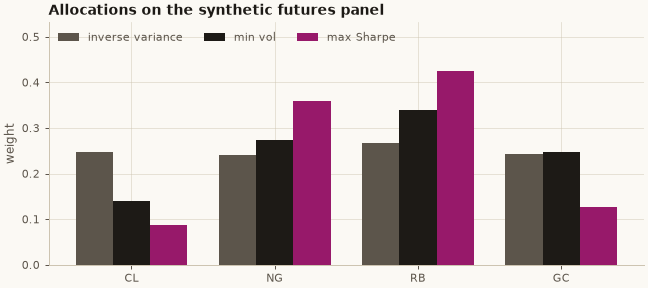

In [3]:
allocations = {"inverse variance": ivp[0], "min vol": mv[0], "max Sharpe": msr[0]}


def draw(fig, c):
    ax = fig.subplots()
    colors = [c["muted"], c["text"], c["accent"]]
    width = 0.26
    for k, (label, weights) in enumerate(allocations.items()):
        xs = [i + (k - 1) * width for i in range(len(ds.asset_names))]
        ax.bar(xs, weights, width=width, color=colors[k], label=label)
    ax.axhline(0.0, color=c["muted"], linewidth=0.8)
    ax.set_xticks(range(len(ds.asset_names)), ds.asset_names)
    ax.set_ylabel("weight")
    ax.set_title("Allocations on the synthetic futures panel")
    ax.set_ylim(0.0, 1.25 * max(max(w) for w in allocations.values()))
    ax.legend(ncols=3, loc="upper left")


nbfigures.figure(
    "nb04-allocations",
    draw,
    alt="Grouped bars comparing inverse-variance, minimum-volatility and maximum-Sharpe weights per asset.",
)